In [1]:
import numpy as np
import scipy
from scipy.sparse.linalg import spsolve
from matplotlib import pyplot as plt

Outline for Simple Least Squares Phase Unwrapping

1) create a smooth function to phase to represent the absalute phase (unwrapped phase) 
2) Truncate the smooth funciton to create the princible phase (wrapped phase) 
3) Demonstrate Itoh's condition
$$
\nabla \phi = W(\nabla \psi)
$$
4) create sparse matrix to represent the gradient opperator
5) solve the least squares phase unwrapping problem by imposing Itoh's condition
$$
\argmin_\phi \| \nabla \phi - W(\nabla \psi) \|^2_2
$$

where $\phi$ is the absalute phase, $\psi$ is the princible phase, and $W$ is the wrapping opperator given by 
$$
W(y): R \rightarrow [- \pi, \pi) = [(y+\pi) \text{ mod } 2 \pi] - \pi
$$




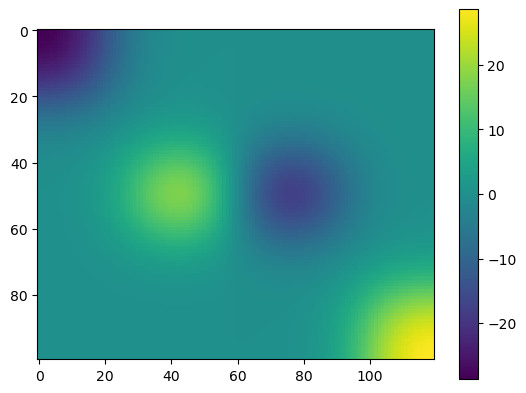

In [2]:

# create a smooth function to phase unwrapp

Nx = 120
Ny = 100

Phi = np.zeros((Ny, Nx))
Phi[40:60, 30:60] = 10*np.pi
Phi[40:60, 60:90] = -10*np.pi
Phi[:20, :20] = -10*np.pi
Phi[-20:, -20:] = 10*np.pi
Phi = scipy.ndimage.gaussian_filter(Phi, sigma=10)

plt.imshow(Phi)
plt.colorbar()




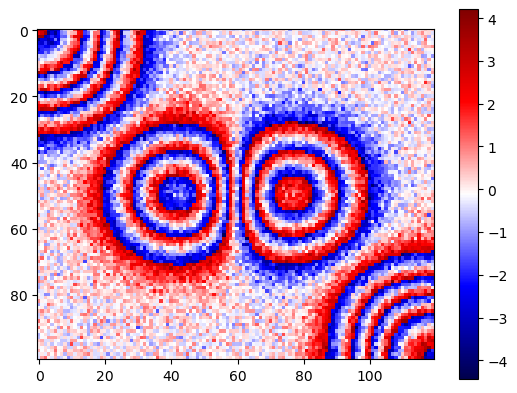

In [3]:
# wrap the absalute phase to come up with the principle phase

def wrap(y): 
	return ((y + np.pi) % (2*np.pi)) - np.pi

Psi = wrap(Phi)
Psi += 0.5*np.random.randn(Psi.shape[0], Psi.shape[1])
plt.imshow(Psi, cmap="seismic")
plt.colorbar()


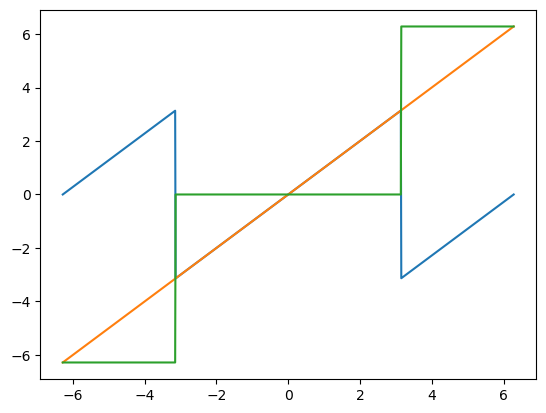

In [4]:
t = np.linspace(-2*np.pi, 2*np.pi, 1000)

plt.plot(t, wrap(t))
plt.plot(t, t)
plt.plot(t, t-wrap(t))
# plt.plot(t, abs(wrap(t)))
# plt.plot(t, abs(wrap(t)) + (2*np.floor(np.abs(t)/np.pi)*np.abs(t) - 2*np.pi*np.floor(np.abs(t)/np.pi)))
# plt.plot(t, abs(wrap(t)) + 2*np.floor(np.abs(t)/np.pi)*(np.abs(t) - np.pi))

([], [])

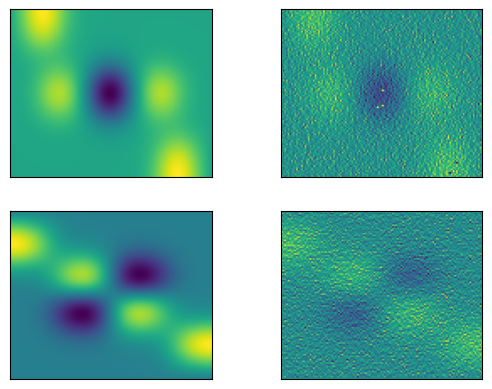

In [5]:
# Demonstate Ithoh's condition

dx_phi = 0.0*Phi
dx_phi[:,:-1] = np.diff(Phi, axis=1)
dy_phi = 0.0*Phi
dy_phi[:-1,:] = np.diff(Phi, axis=0)

dx_psi = 0.0*Psi
dx_psi[:,:-1] = wrap(np.diff(Psi, axis=1))
# dx_psi[:,:-1] = (np.diff(Psi, axis=1))
dy_psi = 0.0*Psi
dy_psi[:-1,:] = wrap(np.diff(Psi, axis=0))
# dy_psi[:-1,:] = (np.diff(Psi, axis=0))

# dx_psi += np.random.randn(dx_psi.shape[0], dx_psi.shape[1])
# dy_psi += np.random.randn(dx_psi.shape[0], dx_psi.shape[1])

plt.subplot(221)
plt.imshow(dx_phi)
plt.xticks([])
plt.yticks([])
plt.subplot(222)
plt.imshow(dx_psi)
plt.xticks([])
plt.yticks([])
plt.subplot(223)
plt.imshow(dy_phi)
plt.xticks([])
plt.yticks([])
plt.subplot(224)
plt.imshow(dy_psi)
plt.xticks([])
plt.yticks([])

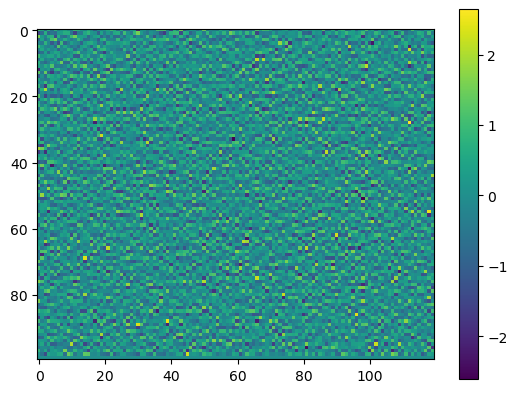

In [6]:
plt.imshow(dy_phi - dy_psi)
plt.colorbar()

In [7]:
# create sparse matrices to represent the descrete gadient opperator (forward difference)

# Nx = 4
# Ny = 5

Nm = Nx * Ny

J, I = np.meshgrid(np.arange(Nx), np.arange(Ny))
I = I.flatten()
J = J.flatten()

bol_top = I == 0
bol_btm = I == Ny-1
bol_lft = J == 0
bol_rht = J == Nx-1

D1 = np.vstack((-np.ones((1, Nm)), np.ones((1, Nm)), np.zeros((1, Nm))))
D1[0,:][bol_rht] = 0.0# 1.0
D1[1,:][bol_rht] = 0.0
D1[2,:][bol_rht] = 0.0# -1.0
D1[1,:] = np.roll(D1[1,:], 1)
D1[2,:] = np.roll(D1[2,:], -1)

Dx = scipy.sparse.spdiags(D1, [0, 1, -1], Nm, Nm, format="csr")

D2 = np.vstack((-np.ones((1, Nm)), np.ones((1, Nm)), np.zeros((1, Nm))))
D2[0,:][bol_btm] = 0.0# 1.0
D2[1,:][bol_btm] = 0.0
D2[2,:][bol_btm] = 0.0# -1.0
D2[1,:] = np.roll(D2[1,:], Nx)
D2[2,:] = np.roll(D2[2,:], -Nx)

Dy = scipy.sparse.spdiags(D2, [0, Nx, -Nx], Nm, Nm, format="csr")

# form gadient opperator
G = scipy.sparse.bmat(
	[
		[Dx],
		[Dy]
	],
	format="csr")

# G = scipy.sparse.bmat(
# 	[
# 		[G, scipy.sparse.csr_matrix((2*Nm, 1))]
# 	], 
# 	format="csr")

last_row_bol_ind = np.ravel_multi_index((Nx-1, 0), (Nx, Ny))
last_row = scipy.sparse.csr_matrix(([1.0], ([0], [last_row_bol_ind])), shape=(1, Nm))

G = scipy.sparse.bmat(
	[
		[G], 
		[last_row]
	], 
	format="csr")

print(G.shape)



(24001, 12000)


In [8]:
# Dy = Dy.toarray()
# plt.imshow(Dy)

In [9]:
# solve least squares unwrapping problem 

# get data vector

# d = np.hstack(
# 	(dx_psi.flatten(), dy_psi.flatten())
# )

d = wrap(G @ Psi.flatten())
# d = np.hstack((Psi.flatten(), 0.0))
# d = G @ d
# d = wrap(d)

RHS = G.T@G
LHS = G.T@d
Phi_star = spsolve(RHS, LHS)


In [10]:
Phi_star[-1]

np.float64(28.26517889368241)

In [11]:
print(d[-1])
print(Psi[-1,0])

0.26747428088251546
-0.3902788486398356


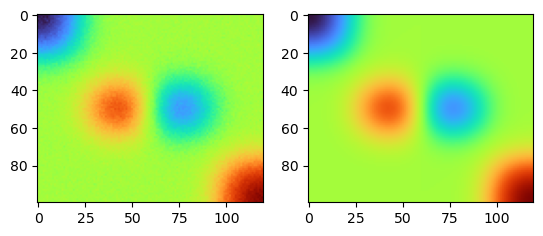

In [12]:
Phi_star = Phi_star.reshape(Phi.shape)
# Phi_star -= Phi_star[0,0] 
# Phi_star += Phi[0,0]

plt.subplot(121)
plt.imshow(Phi_star, cmap="turbo")
plt.subplot(122)
plt.imshow(Phi, cmap="turbo")
# plt.colorbar()

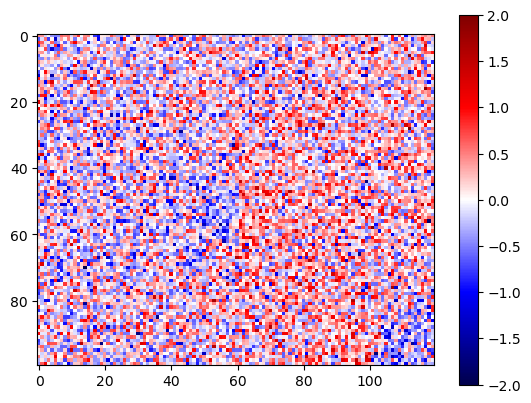

In [13]:
plt.imshow(Phi_star-Phi, cmap="seismic", vmin=-2.0, vmax=2.0)
plt.colorbar()

(array([  11.,  119.,  736., 2121., 3490., 3343., 1653.,  458.,   59.,
          10.]),
 array([-2.02861167e+00, -1.62298939e+00, -1.21736711e+00, -8.11744838e-01,
        -4.06122562e-01, -5.00285787e-04,  4.05121990e-01,  8.10744266e-01,
         1.21636654e+00,  1.62198882e+00,  2.02761109e+00]),
 <BarContainer object of 10 artists>)

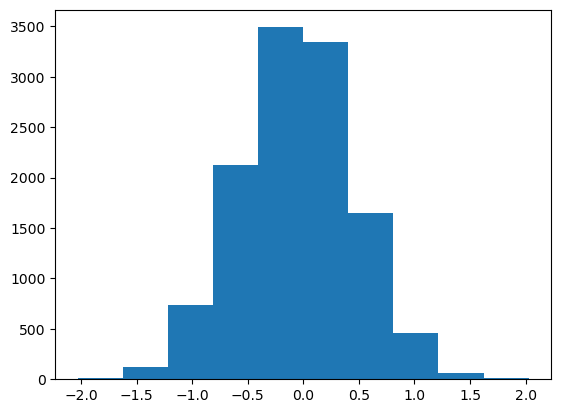

In [14]:
plt.hist((Phi-Phi_star).flatten())

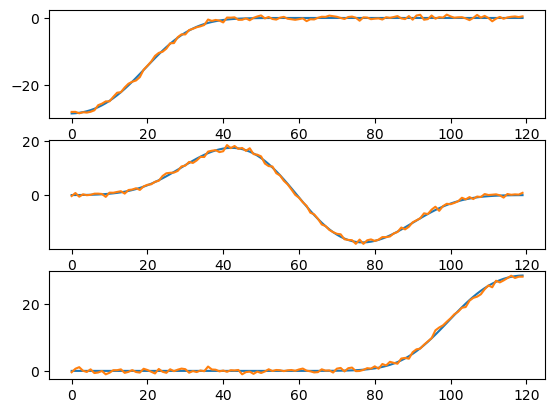

In [15]:
plt.subplot(311)
plt.plot(Phi[0,:])
plt.plot(Phi_star[0,:])
plt.subplot(312)
plt.plot(Phi[50,:])
plt.plot(Phi_star[50,:])
plt.subplot(313)
plt.plot(Phi[-1,:])
plt.plot(Phi_star[-1,:])

In [16]:
RHS

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 59560 stored elements and shape (12000, 12000)>